In [ ]:
!pip install --user tqdm

In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torch.autograd import Variable
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
import os
import cv2
from PIL import Image
from tqdm import tqdm_notebook as tqdm
import random
from matplotlib import pyplot as plt

device = torch.device("cuda: 0" if torch.cuda.is_available() else "cpu")

In [ ]:
class ImageTransform():
  def __init__(self, resize, mean, std):
    self.data_transform = {
        'train':transforms.Compose([
            transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ]),
        'val':transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(resize),
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ])
    }
  def __call__(self, img, phase):
    return self.data_transform[phase](img)

In [ ]:
import os

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/gilbutITbook/080289.git

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 2278 (delta 4), reused 27 (delta 3), pack-reused 2246 (from 1)
Receiving objects: 100% (2278/2278), 330.30 MiB | 50.71 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.


In [ ]:
cat_directory = r'080289/chap06/data/dogs-vs-cats/Cat/'
dog_directory = r'080289/chap06/data/dogs-vs-cats/Dog/'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in os.listdir(dog_directory)])
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths]
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

random.seed(42)
random.shuffle(correct_images_filepaths)
train_images_filepaths = correct_images_filepaths[:400]
val_images_filepaths = correct_images_filepaths[400:-10]
test_images_filepaths = correct_images_filepaths[-10:]
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 92 10


In [ ]:
import os
list_path = ['C:\\', 'Temp', 'user']
folder_path = os.path.join(*list_path)
folder_path

'C:\\/Temp/user'

In [ ]:
import numpy as np

np.random.seed(101)
np.random.randint(low=1, high = 10, size = 10)

array([2, 7, 8, 9, 5, 9, 6, 1, 6, 9])

In [ ]:
np.random.seed(100)
np.random.randint(low=1, high=10, size = 10)

array([9, 9, 4, 8, 8, 1, 5, 3, 6, 3])

In [ ]:
np.random.seed(101)
np.random.randint(low=1, high=10, size=10)

array([2, 7, 8, 9, 5, 9, 6, 1, 6, 9])

In [ ]:
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
  rows = len(images_filepaths) //cols
  figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
  for i, image_filepath in enumerate(images_filepaths):
    image = cv2.imread(image_filepath)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    true_label = os.path.normpath(image_filepath).split(os.sep)[-2]
    predicted_label = predicted_labels[i] if predicted_labels else true_label
    color = "green" if true_label == predicted_label else "red"
    ax.ravel()[i].imshow(image)
    ax.ravel()[i].set_title(predicted_label, color=color)
    ax.ravel()[i].set_axis_off()
  plt.tight_layout()
  plt.show()

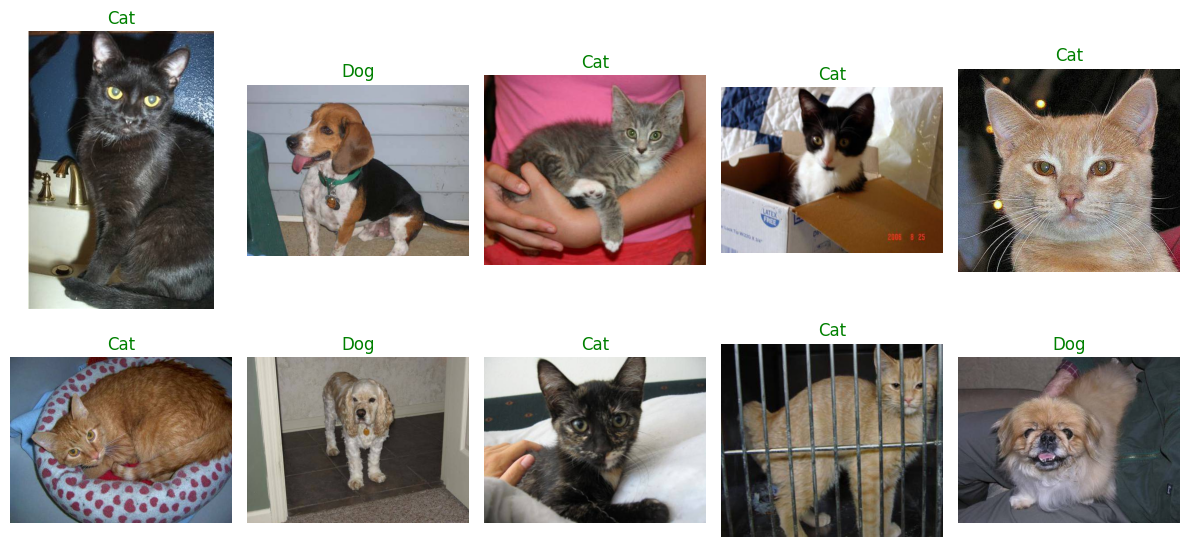

In [ ]:
display_image_grid(test_images_filepaths)

In [ ]:
#이미지 데이터셋 클래스 정의
class DogvsCatDataset(Dataset):
  def __init__(self, file_list, transform=None, phase='train'):
    self.file_list = file_list
    self.transform = transform
    self.phase = phase

  def __len__(self):
    return len(self.file_list)

  def __getitem__(self, idx):
    img_path = self.file_list[idx]
    img = Image.open(img_path)
    img_transformed = self.transform(img, self.phase)
    label = img_path.split('/')[-1].split('.')[0]
    if label == 'dog':
      label = 1
    elif label == 'cat':
      label = 0
    return img_transformed, label

In [ ]:
#변수 값 정의
size = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

In [ ]:
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')
index = 0
print(train_dataset.__getitem__(index)[0].size())
print(train_dataset.__getitem__(index)[1])

torch.Size([3, 224, 224])
0


In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train': train_dataloader, 'val': val_dataloader}

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 224, 224])
tensor([0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
        1, 1, 0, 1, 1, 0, 0, 0])


In [ ]:
class LeNet(nn.Module):
  def __init__(self):
    super(LeNet, self).__init__()
    self.cnn1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1, padding=0)
    self.relu1 = nn.ReLU()
    self.maxpool1 = nn.MaxPool2d(kernel_size=2)
    self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
    self.relu2 = nn.ReLU()
    self.maxpool2 = nn.MaxPool2d(kernel_size=2)

    self.fc1 = nn.Linear(32*53*53, 512)
    self.relu5 = nn.ReLU()
    self.fc2 = nn.Linear(512, 2)
    self.output = nn.Softmax(dim=1)

  def forward(self, x):
    out = self.cnn1(x)
    out = self.relu1(out)
    out = self.maxpool1(out)
    out = self.cnn2(out)
    out = self.relu2(out)
    out = self.maxpool2(out)
    out = out.view(out.size(0), -1)
    out = self.fc1(out)
    out = self.fc2(out)
    out = self.output(out)
    return out

In [ ]:
model = LeNet()
print(model)

LeNet(
  (cnn1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=89888, out_features=512, bias=True)
  (relu5): ReLU()
  (fc2): Linear(in_features=512, out_features=2, bias=True)
  (output): Softmax(dim=1)
)


In [ ]:
!pip install torchsummary

In [ ]:
from torchsummary import summary
summary(model, input_size = (3,224,224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 220, 220]           1,216
              ReLU-2         [-1, 16, 220, 220]               0
         MaxPool2d-3         [-1, 16, 110, 110]               0
            Conv2d-4         [-1, 32, 106, 106]          12,832
              ReLU-5         [-1, 32, 106, 106]               0
         MaxPool2d-6           [-1, 32, 53, 53]               0
            Linear-7                  [-1, 512]      46,023,168
            Linear-8                    [-1, 2]           1,026
           Softmax-9                    [-1, 2]               0
Total params: 46,038,242
Trainable params: 46,038,242
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 19.47
Params size (MB): 175.62
Estimated Total Size (MB): 195.67
--------------------------------

In [ ]:
def count_parameters(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 46,038,242 trainable parameters


In [ ]:
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum = 0.9)
criterion = nn.CrossEntropyLoss()

In [ ]:
#모델의 파라미터와 손실 함수를 cpu에 할당
model = model.to(device)
criterion = criterion.to(device)

In [ ]:
def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
  since = time.time()
  best_acc = 0.0

  for epoch in range(num_epoch):
    print('Epoch {}/{}'.format(epoch+1, num_epoch))
    print('-'*20)

    for phase in ['train', 'val']:
      if phase == 'train':
        model.train()
      else:
        model.eval()
      epoch_loss = 0.0
      epoch_corrects = 0

      for inputs, labels in tqdm(dataloader_dict[phase]):
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        with torch.set_grad_enabled(phase == 'train'):
          outputs = model(inputs)
          _, preds = torch.max(outputs, 1)
          loss = criterion(outputs, labels)

          if phase == 'train':
            loss.backward()
            optimizer.step()
          epoch_loss += loss.item()*inputs.size(0)
          epoch_corrects += torch.sum(preds == labels.data)
  time_elapsed = time.time()
  print('Training compliete in {:.0f}m {:.0f}s'.format(time_elapsed //60, time_elapsed % 60))
  print('Best val Acc: {:4f}'.format(best_acc))
  return model

In [ ]:
import time

num_epoch = 10
model = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/10
--------------------


/tmp/ipykernel_5041/4119898223.py:17: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for inputs, labels in tqdm(dataloader_dict[phase]):


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 2/10
--------------------


...

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch 10/10
--------------------


  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

Training compliete in 29590736m 30s
Best val Acc: 0.000000


In [ ]:
import pandas as pd

id_list = []
pred_list = []
_id = 0
with torch.no_grad():
  for test_path in tqdm(test_images_filepaths):
    img = Image.open(test_path)
    _id = test_path.split('/')[-1].split('.')[1]
    transform = ImageTransform(size, mean, std)
    img = transform(img, phase = 'val')
    img = img.unsqueeze(0)
    img = img.to(device)

    model.eval()
    outputs = model(img)
    preds = F.softmax(outputs, dim=1)[:, 1].tolist()
    id_list.append(_id)
    pred_list.append(preds[0])

res = pd.DataFrame({
    'id':id_list,
    'label': pred_list
})

res.sort_values(by='id', inplace =True)
res.reset_index(drop = True, inplace = True)

res.to_csv('080289/chap06/data/LeNet', index =False)

/tmp/ipykernel_5041/80262826.py:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for test_path in tqdm(test_images_filepaths):


  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
res.head(10)

,id,label
0,109,0.416852
1,145,0.428596
2,15,0.597279
3,162,0.559520
4,167,0.506682
5,200,0.480062
6,210,0.549698
7,211,0.576422
8,213,0.468476
9,224,0.482857


In [ ]:
class_ = classes = {0:'cat', 1:'dog'}
def display_image_grid(images_filepaths, predicted_labels=(), cols = 5):
  rows = len(images_filepaths)//cols
  figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize = (12,6))
  for i, image_filepath in enumerate(images_filepaths):
    image = cv2.imread(image_filepath)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    a = random.choice(res['id'].values)
    label = res.loc[res['id'] == a, 'label'].values[0]
    if label > 0.5:
      label = 1
    else:
      label = 0
    ax.ravel()[i].imshow(image)
    ax.ravel()[i].set_title(class_[label])
    ax.ravel()[i].set_axis_off()
  plt.tight_layout()
  plt.show()

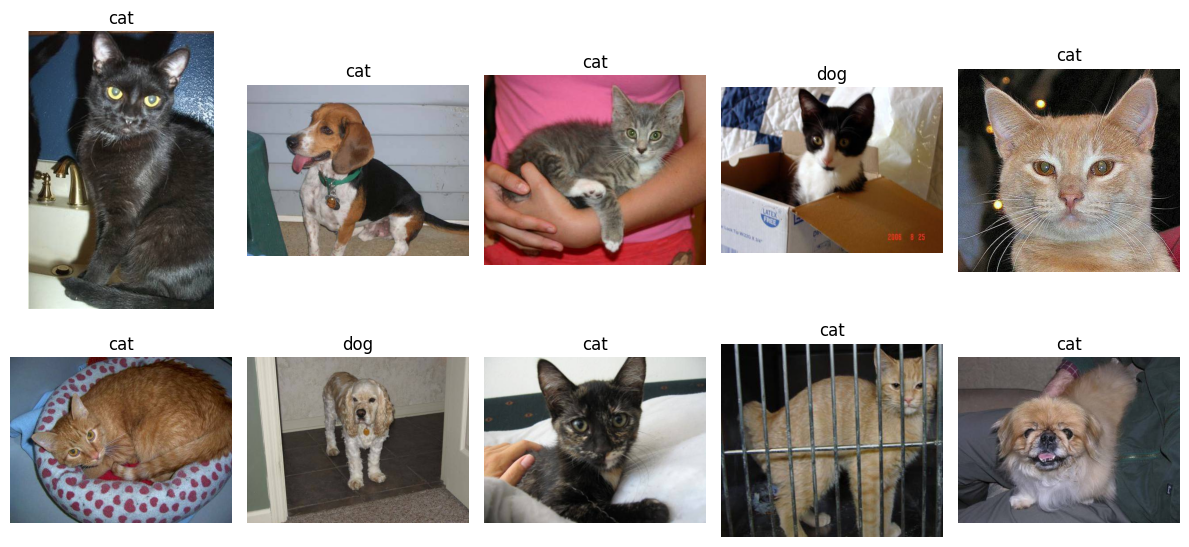

In [ ]:
display_image_grid(test_images_filepaths)

In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torch.autograd import Variable
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
import os
import cv2
from PIL import Image
from tqdm import tqdm_notebook as tqdm
import random
from matplotlib import pyplot as plt

device = torch.device("cuda: 0" if torch.cuda.is_available() else "cpu")

In [ ]:
class ImageTransform():
  def __init__(self, resize, mean, std):
    self.data_transform = {
        'train':transforms.Compose([
            transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ]),
        'val':transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(resize),
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ])
    }
  def __call__(self, img, phase):
    return self.data_transform[phase](img)

In [ ]:
cat_directory = r'080289/chap06/data/dogs-vs-cats/Cat/'
dog_directory = r'080289/chap06/data/dogs-vs-cats/Dog/'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in os.listdir(dog_directory)])
images_filepaths = [*cat_images_filepaths, *dog_images_filepaths]
correct_images_filepaths = [i for i in images_filepaths if cv2.imread(i) is not None]

random.seed(42)
random.shuffle(correct_images_filepaths)
train_images_filepaths = correct_images_filepaths[:400]
val_images_filepaths = correct_images_filepaths[400:-10]
test_images_filepaths = correct_images_filepaths[-10:]
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

400 92 10


In [ ]:
#이미지 데이터셋 클래스 정의
class DogvsCatDataset(Dataset):
  def __init__(self, file_list, transform=None, phase='train'):
    self.file_list = file_list
    self.transform = transform
    self.phase = phase

  def __len__(self):
    return len(self.file_list)

  def __getitem__(self, idx):
    img_path = self.file_list[idx]
    img = Image.open(img_path)
    img_transformed = self.transform(img, self.phase)
    label = img_path.split('/')[-1].split('.')[0]
    if label == 'dog':
      label = 1
    elif label == 'cat':
      label = 0
    return img_transformed, label

In [ ]:
size = 256
'''
AlexNet은 깊이가 깊은 네트워크를 사용하므로
이미지 크기가 256이 아니면 풀링층 때문에 크기가 계속 줄어들어 오류 발생
'''
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

In [ ]:
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')
test_dataset = DogvsCatDataset(test_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')
index = 0
print(train_dataset.__getitem__(index)[0].size())
print(train_dataset.__getitem__(index)[1])

torch.Size([3, 256, 256])
0


In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train': train_dataloader, 'val': val_dataloader}

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 256, 256])
tensor([1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
        1, 0, 1, 0, 0, 0, 0, 1])


In [ ]:
class AlexNet(nn.Module):
  def __init__(self) -> None:
    super(AlexNet, self).__init__()
    self.features = nn.Sequential(
        nn.Conv2d(3,64,kernel_size = 11,stride=4, padding=2),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nn.Conv2d(64,192,kernel_size=5, padding=2),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(kernel_size=3, stride=2),
        nn.Conv2d(192, 384, kernel_size=3, padding=1),
        nn.ReLU(inplace= True),
        nn.Conv2d(384, 256, kernel_size=3, padding=1),
        nn.ReLU(inplace= True),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2)
    )
    self.avgpool = nn.AdaptiveAvgPool2d((6,6))
    self.classifier = nn.Sequential(
        nn.Dropout(),
        nn.Linear(256 *6*6, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(),
        nn.Linear(4096, 512),
        nn.ReLU(inplace=True),
        nn.Linear(512,2)
    )
  def forward(self, x:torch.Tensor) -> torch.Tensor:
    x = self.features(x)
    x = self.avgpool(x)
    x = torch.flatten(x, 1)
    x = self.classifier(x)
    return x


In [ ]:
model = AlexNet()
model.to(device)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum = 0.9)
criterion = nn.CrossEntropyLoss()

In [ ]:
from torchsummary import summary
summary(model, input_size = (3,256,256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 63, 63]          23,296
              ReLU-2           [-1, 64, 63, 63]               0
         MaxPool2d-3           [-1, 64, 31, 31]               0
            Conv2d-4          [-1, 192, 31, 31]         307,392
              ReLU-5          [-1, 192, 31, 31]               0
         MaxPool2d-6          [-1, 192, 15, 15]               0
            Conv2d-7          [-1, 384, 15, 15]         663,936
              ReLU-8          [-1, 384, 15, 15]               0
            Conv2d-9          [-1, 256, 15, 15]         884,992
             ReLU-10          [-1, 256, 15, 15]               0
           Conv2d-11          [-1, 256, 15, 15]         590,080
             ReLU-12          [-1, 256, 15, 15]               0
        MaxPool2d-13            [-1, 256, 7, 7]               0
AdaptiveAvgPool2d-14            [-1, 25

In [ ]:
def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
  since = time.time()
  best_acc = 0.0

  for epoch in range(num_epoch):
    print('Epoch {}/{}'.format(epoch+1, num_epoch))
    print('-'*20)

    for phase in ['train', 'val']:
      if phase == 'train':
        model.train()
      else:
        model.eval()
      epoch_loss = 0.0
      epoch_corrects = 0

      for inputs, labels in tqdm(dataloader_dict[phase]):
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        with torch.set_grad_enabled(phase == 'train'):
          outputs = model(inputs)
          _, preds = torch.max(outputs, 1)
          loss = criterion(outputs, labels)

          if phase == 'train':
            loss.backward()
            optimizer.step()
          epoch_loss += loss.item()*inputs.size(0)
          epoch_corrects += torch.sum(preds == labels.data)
      epoch_loss = epoch_loss/len(dataloader_dict[phase].dataset)
      epoch_acc = epoch_corrects.double()/len(dataloader_dict[phase].dataset)

      print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))
  time_elapsed = time.time() - since
  print('Training compliete in {:.0f}m {:.0f}s'.format(time_elapsed //60, time_elapsed % 60))
  return model

In [ ]:
import time

num_epoch = 10
model = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/10
--------------------


/tmp/ipykernel_9988/2598196879.py:17: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for inputs, labels in tqdm(dataloader_dict[phase]):


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6932 Acc: 0.5025


  0%|          | 0/3 [00:00<?, ?it/s]

...

val Loss: 0.6927 Acc: 0.5109
Epoch 10/10
--------------------


  0%|          | 0/13 [00:00<?, ?it/s]

train Loss: 0.6931 Acc: 0.5050


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.6927 Acc: 0.5109
Training compliete in 8m 32s


In [ ]:
import pandas as pd

id_list = []
pred_list = []
_id = 0
with torch.no_grad():
  for test_path in tqdm(test_images_filepaths):
    img = Image.open(test_path)
    _id = test_path.split('/')[-1].split('.')[1]
    transform = ImageTransform(size, mean, std)
    img = transform(img, phase = 'val')
    img = img.unsqueeze(0)
    img = img.to(device)

    model.eval()
    outputs = model(img)
    preds = F.softmax(outputs, dim=1)[:, 1].tolist()
    id_list.append(_id)
    pred_list.append(preds[0])

res = pd.DataFrame({
    'id':id_list,
    'label': pred_list
})

res.to_csv('080289/chap06/data/alexnet.csv', index =False)

/tmp/ipykernel_9988/3295395193.py:7: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for test_path in tqdm(test_images_filepaths):


  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
res.head(10)

,id,label
0,145,0.503607
1,211,0.504167
2,162,0.503777
3,200,0.505423
4,210,0.504626
5,224,0.503560
6,213,0.503768
7,109,0.504339
8,15,0.503887
9,167,0.503650


In [ ]:
class_ = classes = {0:'cat', 1:'dog'}
def display_image_grid(images_filepaths, predicted_labels=(), cols = 5):
  rows = len(images_filepaths)//cols
  figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize = (12,6))
  for i, image_filepath in enumerate(images_filepaths):
    image = cv2.imread(image_filepath)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    a = random.choice(res['id'].values)
    label = res.loc[res['id'] == a, 'label'].values[0]
    if label > 0.5:
      label = 1
    else:
      label = 0
    ax.ravel()[i].imshow(image)
    ax.ravel()[i].set_title(class_[label])
    ax.ravel()[i].set_axis_off()
  plt.tight_layout()
  plt.show()

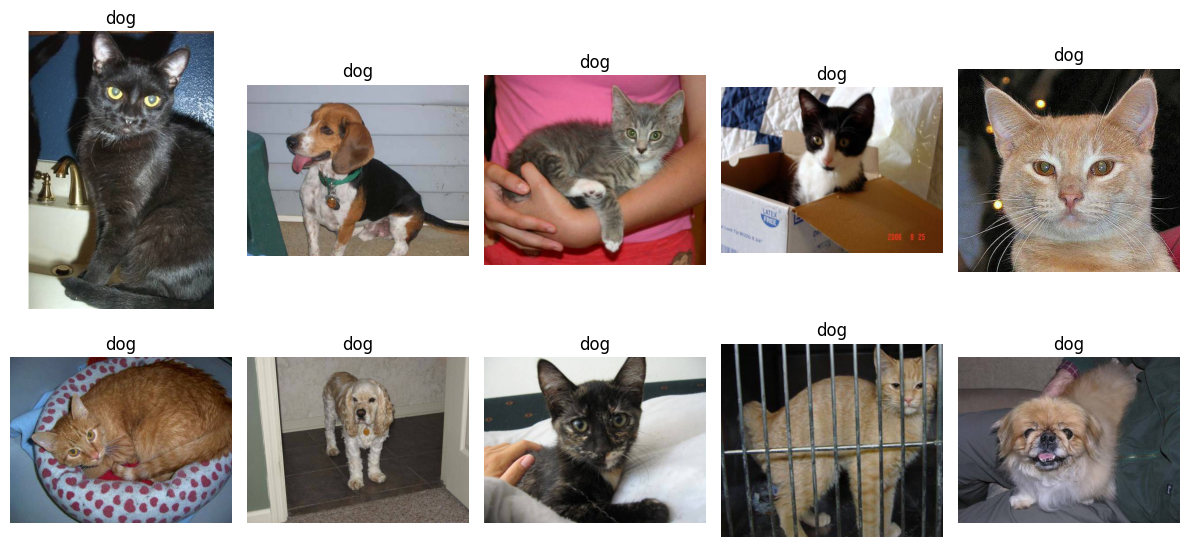

In [ ]:
display_image_grid(test_images_filepaths)

In [ ]:
import copy #객체 복사를 위해 사용
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as Datasets

device = torch.device("cuda: 0" if torch.cuda.is_available() else "cpu")

In [ ]:
#단순한 객체 복사
original = [1,2,3]
copy_o = original
print(copy_o)
copy_o[2] = 10
print(copy_o)
print(original)

[1, 2, 3]
[1, 2, 10]
[1, 2, 10]


In [ ]:
#얕은 복사 -> copy.copy()
import copy

original = [[1,2],3]
copy_o = copy.copy(original)
print(copy_o)
copy_o[0] = 100
print(copy_o)
print(original)

append = copy.copy(original)
append[0].append(4)
print(append)
print(original)

[[1, 2], 3]
[100, 3]
[[1, 2], 3]
[[1, 2, 4], 3]
[[1, 2, 4], 3]


In [ ]:
#깊은 복사 -> copy.deepcopy()
import copy

original = [[1,2],3]
copy_o = copy.deepcopy(original)
print(copy_o)
copy_o[0] = 100
print(copy_o)
print(original)

append = copy.deepcopy(original)
append[0].append(4)
print(append)
print(original)

[[1, 2], 3]
[100, 3]
[[1, 2], 3]
[[1, 2, 4], 3]
[[1, 2], 3]


In [ ]:
#VGG 모델 정의
class VGG(nn.Module):
  def __init__(self, features, output_dim):
    super().__init__()
    self.features = features
    self.avgpool = nn.AdaptiveAvgPool2d(7)
    self.Classifier = nn.Sequential(
        nn.Linear(512*7*7, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(4096, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(4096, output_dim)
    )

  def forward(self,x):
    x = self.features(x) # Corrected typo here
    x = self.avgpool(x)
    h = x.view(x.shape[0], -1)
    x = self.Classifier(h)
    return x,h

In [ ]:
#숫자(output channel, 출력 채널)는 Conv2d를 수행하라는 의미
#M은 최대 풀링을 수행하라는 의미
vgg11_config = [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'] #8(합성곱층) + 3(풀링층) = 11(전체 계층)
vgg13_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'] # 10(합성곱층) + 3(풀링층) = 13
vgg16_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M'] #13 + 3 = 16
vgg19_config = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512, 512, 'M', 512, 512, 512, 512, 'M']

In [ ]:
def get_vgg_layers(config, batch_norm):
  layers = []
  in_channels = 3

  for c in config:
    assert c == 'M' or isinstance(c, int) #assert 뒤의 조건이 True가 아니면 에러 발생
    if c == 'M':
      layers += [nn.MaxPool2d(kernel_size = 2)]
    else:
      conv2d = nn.Conv2d(in_channels, c, kernel_size = 3, padding = 1)
      if batch_norm:
        layers += [conv2d, nn.BatchNorm2d(c), nn.ReLU(inplace=True)]
      else:
        layers += [conv2d, nn.ReLU(inplace = True)]
      in_channels = c

  return nn.Sequential(*layers)

In [ ]:
#assert test
a = 1
assert a == 11

AssertionError: 

In [ ]:
#isinstance는 주어진 조건이 True인지 판단
print(isinstance(1, int))
print(isinstance(1.2, int))
print(isinstance('deep learning', str))

True
False
True


In [ ]:
#모델 계층 생성
vgg11_layers = get_vgg_layers(vgg11_config, batch_norm=True) #batch_norm(Batch Normalization)은 평균을 0으로 표준편차를 1로 분포시킴

In [ ]:
print(vgg11_layers)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (13): ReLU(inplace=True)
  (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, cei

In [ ]:
OUTPUT_DIM = 2
model = VGG(vgg11_layers, OUTPUT_DIM)
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

In [ ]:
import torchvision.models as models
pretrained_model = models.vgg11_bn(pretrained=True)
print(pretrained_model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG11_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG11_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg11_bn-6002323d.pth" to /root/.cache/torch/hub/checkpoints/vgg11_bn-6002323d.pth


100%|██████████| 507M/507M [00:02<00:00, 184MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(5),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224, 0.225])
])
test_transforms = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
])

In [ ]:
train_path = '080289/chap06/data/catanddog/train'
test_path = '080289/chap06/data/catanddog/test'

train_dataset = torchvision.datasets.ImageFolder(
    train_path,
    transform = train_transforms
    )

test_dataset = torchvision.datasets.ImageFolder(
    test_path,
    transform=test_transforms
)

print(len(train_dataset)), print(len(test_dataset))

529
12


(None, None)

In [ ]:
VALID_RATIO = 0.9
n_train_examples = int(len(train_dataset)*VALID_RATIO)
n_valid_examples = len(train_dataset) - n_train_examples

train_data, valid_data = data.random_split(train_dataset, [n_train_examples, n_valid_examples])

In [ ]:
valid_data = copy.deepcopy(valid_data)
valid_data.dataset.transform = test_transforms

In [ ]:
print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(valid_data)}')
print(f'Number of testing examples: {len(test_dataset)}')

Number of training examples: 476
Number of validation examples: 53
Number of testing examples: 12


In [ ]:
BATCH_SIZE = 128
train_iterator = data.DataLoader(train_data, shuffle=True, batch_size = BATCH_SIZE)
valid_iterator = data.DataLoader(valid_data, batch_size = BATCH_SIZE)
test_iterator = data.DataLoader(test_dataset, batch_size = BATCH_SIZE)

In [ ]:
optimizer = optim.Adam(model.parameters(), lr = 1e-7)
criterion = nn.CrossEntropyLoss()

model = model.to(device)
criterion = criterion.to(device)

In [ ]:
def calculate_accuracy(y_pred, y):
  top_pred = y_pred.argmax(1, keepdim=True)
  correct = top_pred.eq(y.view_as(top_pred)).sum() #eq는 equal의 약자/ view_as는 텐서의 크기 사용.
  acc = correct.float()/y.shape[0]
  return acc

In [ ]:
def train(model, iterator, optimizer, criterion, device):
  epoch_loss = 0
  epoch_acc = 0

  model.train()

  for(x,y) in iterator:
    x = x.to(device)
    y = y.to(device)

    optimizer.zero_grad()
    y_pred, _ = model(x)
    loss = criterion(y_pred, y)
    acc = calculate_accuracy(y_pred, y)
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()
    epoch_acc += acc.item()
  return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [ ]:
def evaluate(model, iterator, criterion, device):
  epoch_loss = 0
  epoch_acc = 0

  model.eval()
  with torch.no_grad():
    for (x,y) in iterator:
      x = x.to(device)
      y = y.to(device)
      y_pred, _ = model(x)
      loss = criterion(y_pred, y)
      acc = calculate_accuracy(y_pred, y)

      epoch_loss += loss.item()
      epoch_acc += acc.item()
  return epoch_loss/len(iterator), epoch_acc/len(iterator)

In [ ]:
def epoch_time(start_time, end_time):
  elapsed_time = end_time - start_time
  elapsed_mins = int(elapsed_time/60)
  elapsed_secs = int(elapsed_time - (elapsed_mins*60))
  return elapsed_mins, elapsed_secs

In [ ]:
import time
EPOCHS = 5
best_valid_loss = float('inf')

for epoch in range(EPOCHS):
  start_time = time.monotonic()
  train_loss, train_acc = train(model, train_iterator, optimizer, criterion, device)
  valid_loss, valid_acc = evaluate(model, valid_iterator, criterion, device)
  if valid_loss < best_valid_loss:
    best_valid_loss = valid_loss
    torch.save(model.state_dict(), '080289/chap06/data/VGG-model.pt')

  end_time = time.monotonic()
  epoch_mins, epoch_secs = epoch_time(start_time, end_time)

  print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
  print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
  print(f'\t Valid. Loss: {valid_loss:.3f} | Valid. Acc: {valid_acc*100:.2f}%')

Epoch: 01 | Epoch Time: 3m 11s
	Train Loss: 0.702 | Train Acc: 50.62%
	 Valid. Loss: 0.691 | Valid. Acc: 56.60%
Epoch: 02 | Epoch Time: 3m 10s
	Train Loss: 0.691 | Train Acc: 51.68%
	 Valid. Loss: 0.691 | Valid. Acc: 56.60%
Epoch: 03 | Epoch Time: 3m 11s
	Train Loss: 0.703 | Train Acc: 49.19%
	 Valid. Loss: 0.691 | Valid. Acc: 56.60%
Epoch: 04 | Epoch Time: 3m 11s
	Train Loss: 0.702 | Train Acc: 49.53%
	 Valid. Loss: 0.691 | Valid. Acc: 56.60%
Epoch: 05 | Epoch Time: 3m 9s
	Train Loss: 0.695 | Train Acc: 49.80%
	 Valid. Loss: 0.691 | Valid. Acc: 56.60%


In [ ]:
model.load_state_dict(torch.load('080289/chap06/data/VGG-model.pt'))
test_loss, test_acc = evaluate(model, test_iterator, criterion, device)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Test Loss: 0.694 | Test Acc: 50.00%


In [ ]:
def get_predictions(model, iterator):
  model.eval()
  images = []
  labels = []
  probs = []

  with torch.no_grad():
    for (x,y) in iterator:
      x = x.to(device)
      y_pred, _ = model(x)
      y_prob = F.softmax(y_pred, dim=-1)
      top_pred = y_prob.argmax(1,keepdim=True) #행(axis = 0) 또는 열(axis=1)을 따라 가장 큰 값의 색인을 찾음. 따라서 1은 열을 따라 가장 큰 값의 색인을 찾겠다는 의미. keepdim: 출력 텐서를 입력과 동일한 크기로 유지
      images.append(x.cpu())
      labels.append(y.cpu())
      probs.append(y_prob.cpu())
  images = torch.cat(images, dim = 0) #torch.cat은 텐서를 연결할 때 사용
  labels = torch.cat(labels, dim = 0)
  probs = torch.cat(probs, dim = 0)
  return images, labels, probs

In [ ]:
import torch
x = torch.Tensor([[1,2,3], [2,3,4]])
y = torch.Tensor([[4,5,6], [5,6,7]])

print(torch.cat([x], dim =0))
print('-------------')
print(torch.cat([x,y]))
print('-------------')
print(torch.cat([x,y], dim =0))
print(torch.cat([x,y], dim =1))

tensor([[1., 2., 3.],
        [2., 3., 4.]])
-------------
tensor([[1., 2., 3.],
        [2., 3., 4.],
        [4., 5., 6.],
        [5., 6., 7.]])
-------------
tensor([[1., 2., 3.],
        [2., 3., 4.],
        [4., 5., 6.],
        [5., 6., 7.]])
tensor([[1., 2., 3., 4., 5., 6.],
        [2., 3., 4., 5., 6., 7.]])


In [ ]:
images, labels, probs = get_predictions(model, test_iterator)
pred_labels = torch.argmax(probs, 1)
corrects = torch.eq(labels, pred_labels)
correct_examples = []

for image, label, prob, correct in zip(images, labels, probs, corrects):
  if correct:
    correct_examples.append((image, label, prob))

correct_examples.sort(reverse=True, key = lambda x: torch.max(x[2], dim=0).values)

In [ ]:
x=torch.rand(5,3)
print(x)

tensor([[0.2378, 0.1514, 0.1751],
        [0.5280, 0.1149, 0.5521],
        [0.0819, 0.4562, 0.2334],
        [0.5580, 0.9799, 0.8936],
        [0.4151, 0.5154, 0.3419]])


In [ ]:
print(torch.max(x))
print('--------------')
print(torch.argmax(x))

tensor(0.9799)
--------------
tensor(10)


In [ ]:
a = [1,2,3]
b = ['a', 'b', 'c']

for x,y in zip(a,b):
  print(x,y)

1 a
2 b
3 c


In [ ]:
x = [1,7,3,9]
x.sort(reverse = True)
print('x:', x)

x: [9, 7, 3, 1]


In [ ]:
x = torch.randn([4,4])
print(x)

max_elements, max_idxs = torch.max(x, dim=0)
print(max_elements)
print(max_idxs)

tensor([[-0.8086,  0.7652, -0.5793, -1.4788],
        [ 0.5524, -0.6994, -1.1141,  0.2470],
        [ 0.0114,  1.1709, -2.1628, -0.4824],
        [ 0.1270, -0.5523,  0.2454, -0.2282]])
tensor([0.5524, 1.1709, 0.2454, 0.2470])
tensor([1, 2, 3, 1])


In [ ]:
def normalize_image(image):
  image_min = image.min()
  image_max = image.max()
  image.clamp_(min=image_min, max=image_max)
  image.add_(-image_min).div_(image_max -image_min+1e-5)
  return image

In [ ]:
x = torch.tensor([1,2])
y = x.add(10)
print(y)
print(x is y)
print('-----------')
y = x.add_(10)
print(y)
print(x is y)

tensor([11, 12])
False
-----------
tensor([11, 12])
True


In [ ]:
def plot_most_correct(correct, classes, n_images, normalize=True):
  rows = int(np.sqrt(n_images))
  cols = int(np.sqrt(n_images))
  fig = plt.figure(figsize = (25,20))
  for i in range(rows*cols):
    ax = fig.add_subplot(rows, cols, i+1)
    image, true_label, probs =correct[i]
    image = image.permute(1,2,0)
    true_prob = probs[true_label]
    correct_prob, correct_label = torch.max(probs, dim=0)
    true_class = classes[true_label]
    correct_class = classes[correct_label]
    if normalize:
      image = normalize_image(image)

    ax.imshow(image.cpu().numpy())
    ax.set_title(f'true label: {true_class} ({true_prob:.3f})\n' f'pred_label: {correct_class} ({correct_prob:.3f})')
    ax.axis('off')

  fig.subplots_adjust(hspace=0.4)

In [ ]:
x = torch.tensor([[1,2,3],[4,5,6]])
print(x)
x.permute(1,0)

tensor([[1, 2, 3],
        [4, 5, 6]])


tensor([[1, 4],
        [2, 5],
        [3, 6]])

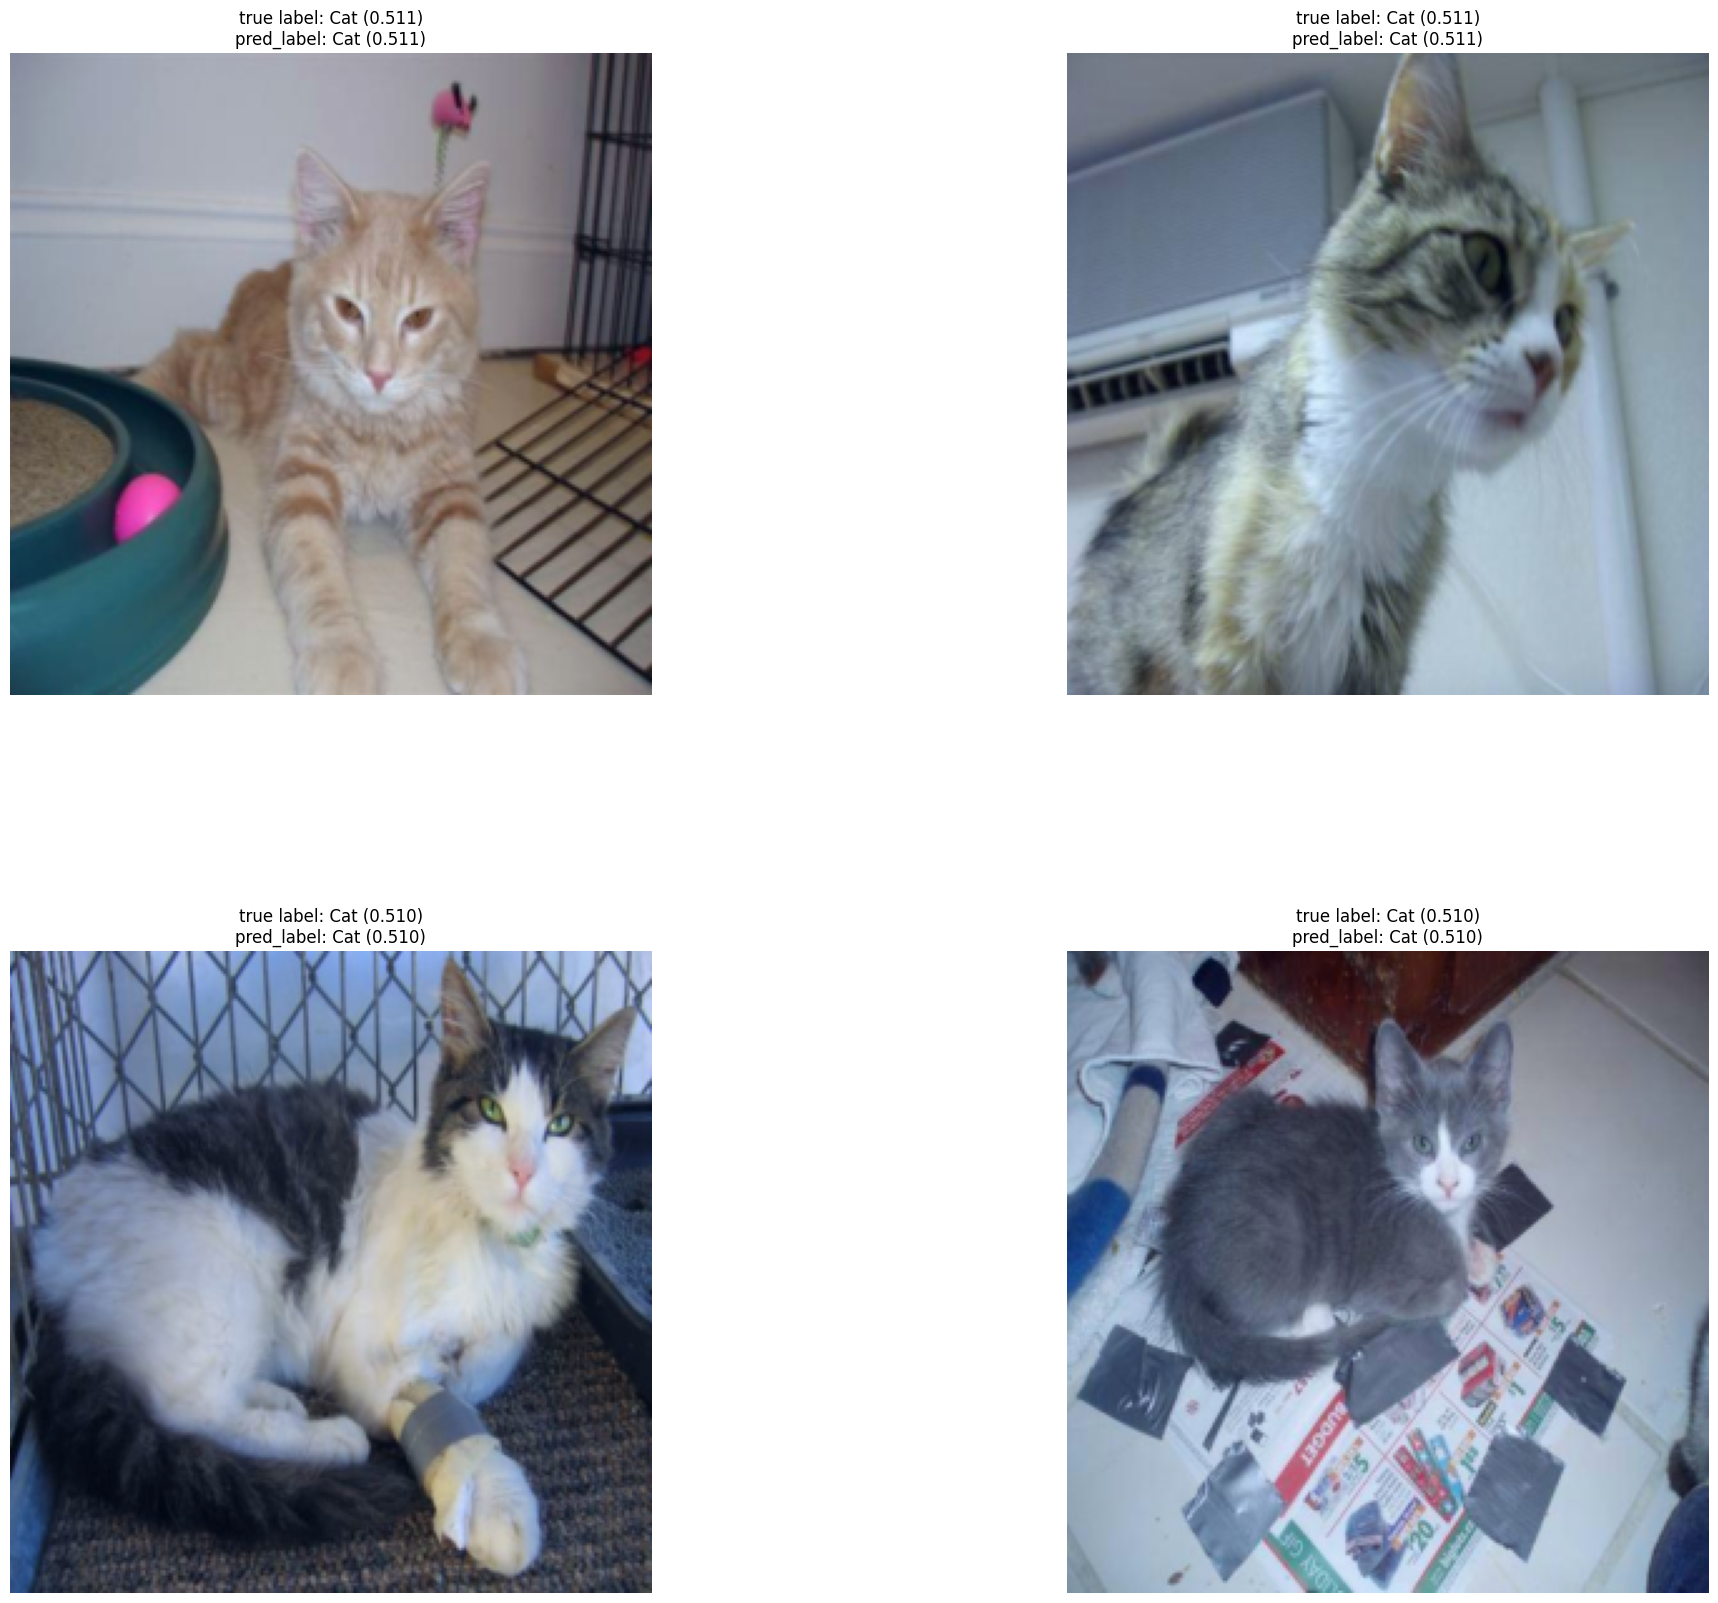

In [ ]:
import matplotlib.pyplot as plt

classes = test_dataset.classes
N_IMAGES = 5
plot_most_correct(correct_examples, classes, N_IMAGES)